# Deforestación Perú — Descarga y Exploración del GeoJSON

**Curso:** MIA-07 Redes Neuronales y Aprendizaje Profundo — Sección B  
**Proyecto final:** Detección de deforestación en imágenes satelitales

Este notebook hace lo siguiente:

1. Descarga `deforestacion.geojson` desde un bucket S3 público (`osmseed-dev/test/`).
2. Carga el archivo con `geopandas`.
3. Explora la estructura del dataset: CRS, columnas, número de polígonos, fuente, fechas, distribución geográfica.
4. Visualiza los polígonos en un mapa interactivo (`folium`) y en un plot estático (`matplotlib`).

El GeoJSON contiene polígonos de zonas deforestadas en el Perú, mapeadas por **SERFOR** (Servicio Nacional Forestal y de Fauna Silvestre). Servirá como **ground truth** (etiquetas) para entrenar la red U-Net que detectará deforestación a partir de imágenes Sentinel-2.

## 1. Instalación de dependencias

Si no tienes estas librerías, descomenta y ejecuta la celda.

In [17]:
!pip install geopandas folium matplotlib requests

## 1.5 Almacenamiento — Google Drive (Colab) o local

En **Colab** montamos Google Drive y guardamos los datos ahí, así persisten entre sesiones (Colab borra `/content` al desconectar). En **local** se usa `./data`.

Todos los notebooks de este proyecto deben usar `DATA_DIR` para leer/escribir, así la misma ruta sirve en Colab y en local.

> Nota: el GeoJSON pesa ~18 MB y va bien en Drive. Para las **imágenes Sentinel-2** (notebook 02, decenas de GB) guárdalas en Drive como almacén, pero en el **entrenamiento** cópialas a `/content` (disco local de la VM) y entrena desde ahí — leer miles de parches directo de Drive es lento.

In [18]:
# === Configuración de almacenamiento ===
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    # Carpeta del proyecto dentro de tu Google Drive
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Entorno: {'Colab + Drive' if IN_COLAB else 'Local'}")
print(f"Datos en: {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab + Drive
Datos en: /content/drive/MyDrive/deforestacion-peru/data


## 2. Descarga del GeoJSON desde S3 público

El archivo está alojado en:

```
s3://osmseed-dev/test/deforestacion.geojson
```

Como es un bucket público, se puede acceder vía HTTPS sin credenciales AWS.

In [19]:
from pathlib import Path
import requests

URL = "https://osmseed-dev.s3.amazonaws.com/test/deforestacion.geojson"
OUTPUT_PATH = DATA_DIR / "deforestacion.geojson"

if OUTPUT_PATH.exists():
    size_mb = OUTPUT_PATH.stat().st_size / 1e6
    print(f"✔ Archivo ya descargado: {OUTPUT_PATH} ({size_mb:.1f} MB)")
else:
    print(f"Descargando desde {URL} ...")
    with requests.get(URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(OUTPUT_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    size_mb = OUTPUT_PATH.stat().st_size / 1e6
    print(f"✔ Descargado: {OUTPUT_PATH} ({size_mb:.1f} MB)")

✔ Archivo ya descargado: /content/drive/MyDrive/deforestacion-peru/data/deforestacion.geojson (18.6 MB)


## 3. Carga con GeoPandas

`geopandas` lee GeoJSON directamente como un DataFrame con geometría.

In [20]:
import geopandas as gpd

gdf = gpd.read_file(OUTPUT_PATH)
print(f"Filas (polígonos): {len(gdf):,}")
print(f"CRS: {gdf.crs}")
print(f"Tipos de geometría: {gdf.geom_type.value_counts().to_dict()}")
print(f"Bounding box (lon_min, lat_min, lon_max, lat_max):\n  {gdf.total_bounds}")
gdf.head(3)

Filas (polígonos): 9,910
CRS: EPSG:4326
Tipos de geometría: {'MultiPolygon': 9910}
Bounding box (lon_min, lat_min, lon_max, lat_max):
  [-78.42624664 -14.07508973 -68.98965832  -0.23299341]


,OBJECTID,FUENTE,DOCREG,FECREG,OBSERV,ZONUTM,ORIGEN,REPOR,CODOBJ,FESATA,...,COORNO,TIPRO,ESTADO,Shape_STAr,Shape_STLe,ORIG_FID,contacto,correo,descarga,geometry
0,18885.0,UMS - SERFOR,None,None,Area de afectacion en la Zona Norte de la Pamp...,19,2,RCU_001_2017,1,2016-12-01,...,8.581084e+06,0,2.0,0.000002,0.008766,0,931381206,juan.suyo@geogpsperu.com,www.geogpsperu.com,"MULTIPOLYGON (((-69.9703 -12.83254, -69.9703 -..."
1,18886.0,UMS - SERFOR,None,None,Area de afectacion en la Zona Norte de la Pamp...,19,2,RCU_001_2017,2,2016-12-01,...,8.580587e+06,0,2.0,0.000007,0.025974,1,931381206,juan.suyo@geogpsperu.com,www.geogpsperu.com,"MULTIPOLYGON (((-69.97326 -12.83542, -69.97326..."
2,18887.0,UMS - SERFOR,None,None,Area de afectacion en la Zona Norte de la Pamp...,19,2,RCU_001_2017,3,2016-12-01,...,8.580393e+06,0,2.0,0.000002,0.007111,2,931381206,juan.suyo@geogpsperu.com,www.geogpsperu.com,"MULTIPOLYGON (((-69.98239 -12.83864, -69.98239..."


## 4. Exploración de columnas y atributos

In [21]:
print("Columnas disponibles:\n")
for col in gdf.columns:
    print(f"  - {col}")

Columnas disponibles:

  - OBJECTID
  - FUENTE
  - DOCREG
  - FECREG
  - OBSERV
  - ZONUTM
  - ORIGEN
  - REPOR
  - CODOBJ
  - FESATA
  - FESATB
  - SATELITE
  - SUPAFEC
  - DRIVER
  - VERAFECT
  - CATEG
  - NOMCATEG
  - DOCLEG
  - NOMTIT
  - DOCAUT
  - CPPCER
  - NOMDIS
  - NOMPRO
  - NOMDEP
  - COORES
  - COORNO
  - TIPRO
  - ESTADO
  - Shape_STAr
  - Shape_STLe
  - ORIG_FID
  - contacto
  - correo
  - descarga
  - geometry


In [22]:
# Fuente de los datos
print("FUENTE de los polígonos:")
print(gdf["FUENTE"].value_counts())

FUENTE de los polígonos:
FUENTE
UMS - SERFOR    9910
Name: count, dtype: int64


In [23]:
# Fechas de afectación (rango temporal del dataset)
import pandas as pd

gdf["FESATA_dt"] = pd.to_datetime(gdf["FESATA"], errors="coerce")
gdf["FESATB_dt"] = pd.to_datetime(gdf["FESATB"], errors="coerce")

print(f"Fecha satélite A — mínima: {gdf['FESATA_dt'].min()}")
print(f"Fecha satélite A — máxima: {gdf['FESATA_dt'].max()}")
print(f"Fecha satélite B — mínima: {gdf['FESATB_dt'].min()}")
print(f"Fecha satélite B — máxima: {gdf['FESATB_dt'].max()}")
print("\nDistribución por año de detección:")
print(gdf["FESATB_dt"].dt.year.value_counts().sort_index())

Fecha satélite A — mínima: 2016-12-01 00:00:00
Fecha satélite A — máxima: 2019-11-22 00:00:00
Fecha satélite B — mínima: 2017-07-04 00:00:00
Fecha satélite B — máxima: 2020-11-18 00:00:00

Distribución por año de detección:
FESATB_dt
2017.0    3431
2018.0    5845
2019.0      57
2020.0     445
Name: count, dtype: int64


In [24]:
# Superficie afectada (columna SUPAFEC, asumida en hectáreas)
print("Estadísticas de superficie afectada (SUPAFEC):")
print(gdf["SUPAFEC"].describe())
print(f"\nTotal de superficie afectada: {gdf['SUPAFEC'].sum():,.1f}")

Estadísticas de superficie afectada (SUPAFEC):
count    9910.000000
mean        4.804456
std        29.545831
min         0.000000
25%         0.080000
50%         0.300000
75%         1.030000
max       505.760000
Name: SUPAFEC, dtype: float64

Total de superficie afectada: 47,612.2


In [25]:
# Driver (causa) de la deforestación
if "DRIVER" in gdf.columns:
    print("Distribución de DRIVER (causa de deforestación):")
    print(gdf["DRIVER"].value_counts())

Distribución de DRIVER (causa de deforestación):
DRIVER
2    7192
1    1504
3    1206
8       8
Name: count, dtype: int64


## 5. Visualización geográfica

### 5.1 Plot estático con matplotlib

/tmp/ipykernel_2814/1983927323.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


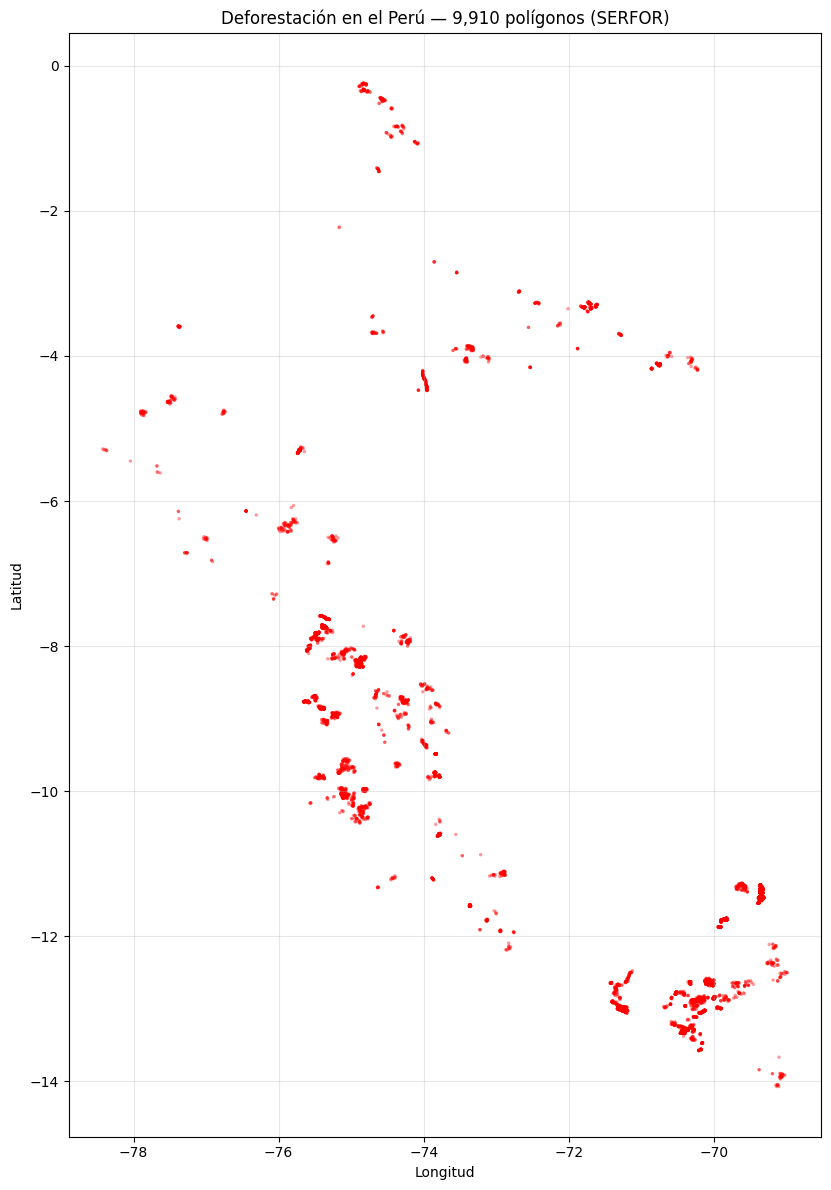

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

# Los polígonos de deforestación son muy pequeños (~pocas hectáreas): a escala
# nacional se ven como 1 píxel. Dibujamos los CENTROIDES como puntos para que la
# distribución geográfica sea visible.
centroids = gdf.geometry.centroid
ax.scatter(centroids.x, centroids.y, s=6, c="red", alpha=0.4, edgecolors="none")

ax.set_title(f"Deforestación en el Perú — {len(gdf):,} polígonos (SERFOR)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(DATA_DIR / "deforestacion_overview.png"), dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Mapa interactivo con Folium

Mostramos solo una muestra de polígonos para no sobrecargar el mapa.

In [27]:
import folium

# Centro aproximado del bbox
minx, miny, maxx, maxy = gdf.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]

m = folium.Map(location=center, zoom_start=6, tiles="OpenStreetMap")

# Tomamos una muestra para que el mapa no pese demasiado
# Convertimos columnas datetime a string (folium/json no las serializa)
sample = gdf.sample(n=min(500, len(gdf)), random_state=42).copy()
for col in sample.select_dtypes(include=['datetime64[ns]']).columns:
    sample[col] = sample[col].astype(str)

folium.GeoJson(
    sample.to_json(),
    name="Deforestación (muestra)",
    style_function=lambda x: {
        "fillColor": "#d62728",
        "color": "#7f0000",
        "weight": 0.5,
        "fillOpacity": 0.6,
    },
).add_to(m)

folium.LayerControl().add_to(m)
m.save(str(DATA_DIR / "deforestacion_mapa.html"))
m

## 7. Descarga de imágenes Sentinel-2 (muestra) + tracking de descargas

Bajamos algunas imágenes **Sentinel-2 RGB** (bandas B04/B03/B02, 10 m) sobre los polígonos de deforestación, usando el catálogo público **STAC earth-search (Element84)** — no requiere credenciales. Lee solo el recorte del polígono desde los COG en AWS (`sentinel-cogs`, egress gratis), no la escena completa.

**Tracking / no re-descargar:** llevamos un `sentinel_manifest.json` en `DATA_DIR` (en Drive si estás en Colab). Cada imagen se registra por su `OBJECTID`. Antes de bajar, revisamos el manifest: si el `OBJECTID` ya existe y el archivo está en disco, se salta. Así puedes correr la celda muchas veces sin bajar dos o tres veces lo mismo, y el registro sobrevive a desconexiones de Colab porque vive en Drive.

In [28]:
# Instala dependencias de imágenes satelitales.
# IMPORTANTE (Colab): rasterio trae su propia GDAL y puede chocar con la de
# geopandas -> crash nativo "malloc(): invalid size" + kernel reiniciado.
# Si pasa: Menú "Entorno de ejecución" -> "Reiniciar entorno de ejecución",
# y luego NO vuelvas a correr esta celda; sigue desde la celda de imports.
!pip install -q rasterio pystac-client shapely

In [29]:
# === Sentinel-2: configuración y manifest de descargas ===
import json
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from pystac_client import Client

STAC_URL   = "https://earth-search.aws.element84.com/v1"
COLLECTION = "sentinel-2-l2a"
BANDS      = ["red", "green", "blue"]   # B04, B03, B02 (10 m)

IMG_DIR       = DATA_DIR / "sentinel_rgb"
MANIFEST_PATH = DATA_DIR / "sentinel_manifest.json"
IMG_DIR.mkdir(parents=True, exist_ok=True)

def load_manifest():
    """Lee el manifest (qué OBJECTID ya se bajaron). Dict keyed por OBJECTID."""
    if MANIFEST_PATH.exists():
        return json.loads(MANIFEST_PATH.read_text())
    return {}

def save_manifest(m):
    MANIFEST_PATH.write_text(json.dumps(m, indent=2, ensure_ascii=False))

def stretch(a, lo=2, hi=98):
    """Estiramiento por percentiles solo para visualizar (no toca el GeoTIFF guardado)."""
    a = a.astype("float32")
    p_lo, p_hi = np.percentile(a, [lo, hi])
    return np.clip((a - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)

manifest = load_manifest()
print(f"Manifest: {len(manifest)} imágenes ya registradas -> {MANIFEST_PATH}")

Manifest: 6 imágenes ya registradas -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_manifest.json


In [30]:
from datetime import datetime, timedelta

def download_rgb(row_id, objectid, geometry, fesatb, manifest,
                 buffer_deg=0.005, window_days=120, max_cloud=30):
    """Descarga RGB Sentinel-2 para un polígono y lo guarda como GeoTIFF.

    Key del manifest = row_id (índice de fila del GeoDataFrame), que SÍ es único.
    OJO: OBJECTID tiene duplicados en este dataset, por eso no se usa como key.
    Si el row_id ya está en el manifest y el archivo existe, NO vuelve a bajar.
    Devuelve el registro del manifest, o None si no hubo escena disponible.
    """
    key = str(int(row_id))
    rec = manifest.get(key)
    if rec and Path(rec["path"]).exists():
        print(f"[skip] fila {key} (OID {int(objectid)}) ya descargada -> {rec['path']}")
        return rec

    minx, miny, maxx, maxy = geometry.bounds
    bbox = (minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg)

    db = datetime.strptime(str(fesatb)[:10].replace("-", "/"), "%Y/%m/%d")
    start = (db - timedelta(days=window_days)).strftime("%Y-%m-%d")
    end   = (db + timedelta(days=window_days)).strftime("%Y-%m-%d")

    search = Client.open(STAC_URL).search(
        collections=[COLLECTION], bbox=list(bbox),
        datetime=f"{start}/{end}",
        query={"eo:cloud_cover": {"lt": max_cloud}}, max_items=15,
    )
    items = sorted(search.items(), key=lambda it: it.properties["eo:cloud_cover"])
    if not items:
        print(f"[warn] fila {key}: sin escena con nubes <{max_cloud}% en +-{window_days}d")
        return None
    item = items[0]

    bands, win_transform, src_crs, prof = [], None, None, None
    with rasterio.Env(AWS_NO_SIGN_REQUEST="YES"):
        for b in BANDS:
            with rasterio.open(item.assets[b].href) as src:
                l, bm, r, t = transform_bounds("EPSG:4326", src.crs, *bbox)
                win = from_bounds(l, bm, r, t, src.transform)
                bands.append(src.read(1, window=win))
                if win_transform is None:
                    win_transform = src.window_transform(win)
                    src_crs, prof = src.crs, src.profile

    out_path = IMG_DIR / f"s2_rgb_{key}.tif"
    prof.update(count=3, dtype="uint16", driver="GTiff", compress="deflate",
                height=bands[0].shape[0], width=bands[0].shape[1],
                transform=win_transform, crs=src_crs)
    with rasterio.open(out_path, "w", **prof) as dst:
        for i, b in enumerate(bands):
            dst.write(b.astype("uint16"), i + 1)

    rec = {
        "row_id": key, "objectid": str(int(objectid)), "stac_item": item.id,
        "datetime": str(item.datetime)[:10],
        "cloud": round(float(item.properties["eo:cloud_cover"]), 1),
        "bbox": [round(v, 5) for v in bbox],
        "path": str(out_path), "status": "ok",
    }
    manifest[key] = rec
    save_manifest(manifest)
    print(f"[ok]   fila {key} (OID {int(objectid)}) -> {item.id} ({rec['datetime']}, nubes {rec['cloud']}%)")
    return rec


def show_rgb(rec, gdf, ax):
    """Dibuja el RGB guardado + el polígono de deforestación (borde amarillo) encima."""
    with rasterio.open(rec["path"]) as src:
        rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
        crs = src.crs
        bnd = src.bounds
    disp = np.dstack([stretch(rgb[..., i]) for i in range(3)])
    ax.imshow(disp, extent=(bnd.left, bnd.right, bnd.bottom, bnd.top))
    poly = gdf.loc[[int(rec["row_id"])]].to_crs(crs)
    poly.boundary.plot(ax=ax, color="yellow", linewidth=1.5)
    ax.set_title(f"OID {rec['objectid']} | {rec['datetime']} | nubes {rec['cloud']}%", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

Procesando 6 polígonos de muestra...

[skip] fila 9552 (OID 28657) ya descargada -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9552.tif
[skip] fila 9692 (OID 28659) ya descargada -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9692.tif
[skip] fila 9691 (OID 28658) ya descargada -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9691.tif
[skip] fila 9695 (OID 28662) ya descargada -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9695.tif
[skip] fila 9854 (OID 28821) ya descargada -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9854.tif
[skip] fila 9753 (OID 28720) ya descargada -> /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9753.tif


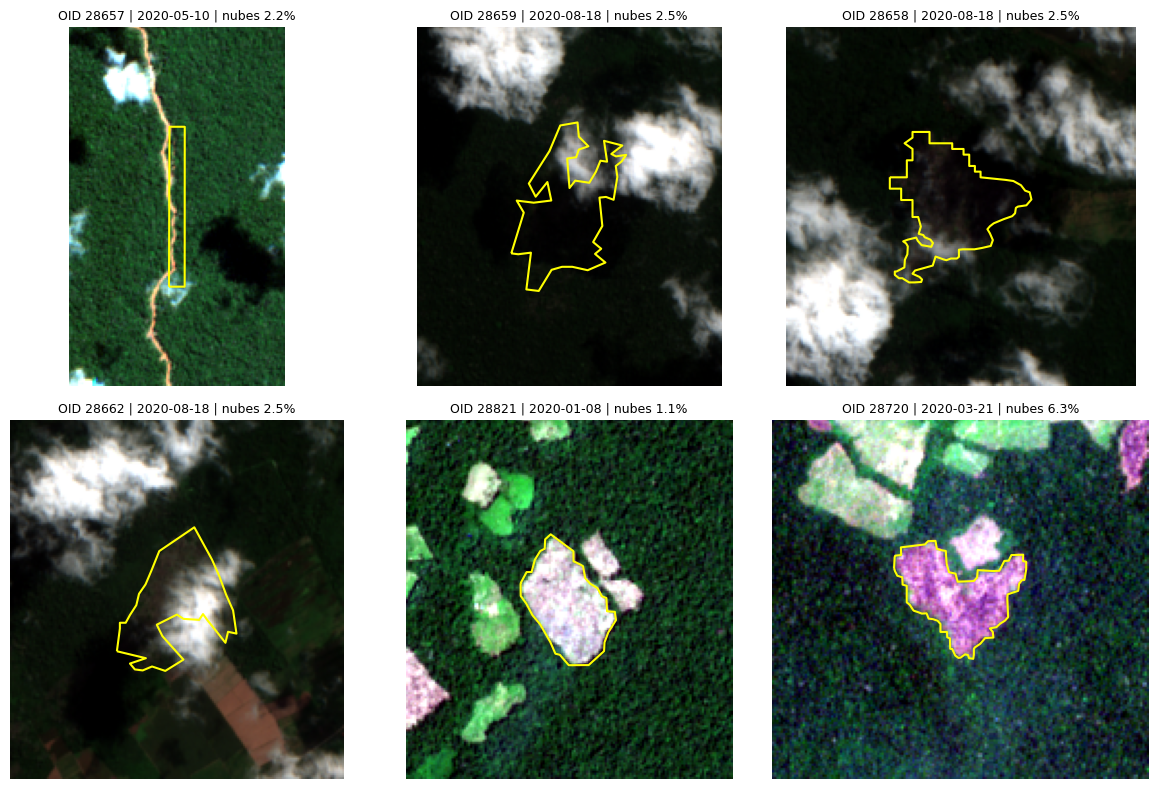

In [31]:
import matplotlib.pyplot as plt

# Muestra: detecciones recientes (>=2020) y de mayor superficie. Son mas visibles
# y tienen mejor cobertura en el archivo COG de Sentinel-2 (escaso antes de 2018).
sample = (gdf[gdf["FESATB_dt"].dt.year >= 2020]
          .drop_duplicates(subset="OBJECTID")
          .sort_values("SUPAFEC", ascending=False)
          .head(6))
print(f"Procesando {len(sample)} polígonos de muestra...\n")

recs = []
for row_id, row in sample.iterrows():
    rec = download_rgb(row_id, row["OBJECTID"], row.geometry, row["FESATB"], manifest)
    if rec:
        recs.append(rec)

# Grilla de previews
cols = 3
rows = (len(recs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.ravel(axes)
for ax in axes:
    ax.axis("off")
for ax, rec in zip(axes, recs):
    show_rgb(rec, gdf, ax)
plt.tight_layout()
plt.savefig(str(DATA_DIR / "sentinel_muestra.png"), dpi=110, bbox_inches="tight")
plt.show()

In [32]:
# Estado del tracking de descargas
m = load_manifest()
print(f"Total imágenes en manifest: {len(m)}\n")
df_m = pd.DataFrame(m.values())
if len(df_m):
    print(df_m[["row_id", "objectid", "datetime", "cloud", "path"]].to_string(index=False))

Total imágenes en manifest: 6

row_id objectid   datetime  cloud                                                                        path
  9552    28657 2020-05-10    2.2 /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9552.tif
  9692    28659 2020-08-18    2.5 /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9692.tif
  9691    28658 2020-08-18    2.5 /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9691.tif
  9695    28662 2020-08-18    2.5 /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9695.tif
  9854    28821 2020-01-08    1.1 /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9854.tif
  9753    28720 2020-03-21    6.3 /content/drive/MyDrive/deforestacion-peru/data/sentinel_rgb/s2_rgb_9753.tif


## 8. Próximos pasos

Ya tenemos las **etiquetas** (polígonos SERFOR) y, en la sección 7, una **muestra de imágenes Sentinel-2 RGB** descargadas vía STAC con su manifest de tracking. La descarga ya vive en este notebook — no hace falta otro para empezar.

Lo que falta para entrenar la U-Net:

- **Escalar la descarga** (este mismo flujo, en `02_descarga_sentinel2.ipynb` o aquí): correr `download_rgb` sobre todos los polígonos por lotes, sumando la banda **NIR** (asset `nir`, ya disponible en el mismo item STAC). El manifest evita re-descargas, así puedes pausar y reanudar.
- `03_generar_mascaras.ipynb`: rasterizar los polígonos sobre cada imagen → máscaras binarias (deforestado / no deforestado).
- `04_dataset_parches.ipynb`: cortar imágenes y máscaras en parches 256×256 → dataset PyTorch.
- `05_modelo_unet.ipynb`: entrenar U-Net. Copia el dataset de Drive a `/content` antes de entrenar (lectura rápida).
- `06_evaluacion.ipynb`: IoU, F1, Dice, visualizaciones.

> Nota: ya **no** usamos Google Earth Engine ni Sentinel Hub. STAC earth-search (sin credenciales, lee COGs públicos en AWS) cubre lo que necesitamos.

### Schema sintético de la pipeline

```
GeoJSON (etiquetas)  +  Sentinel-2 (STAC earth-search)
          |                          |
     rasterización             normalización
          |                          |
     máscara binaria  ----->  parches 256x256
                                     |
                                  U-Net
                                     |
                          máscara predicha + IoU
```